In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [17]:
a = pd.read_csv('../runs/pitch_eval/streaming_compare_20260530_165807/f0_compare.csv')

In [29]:
cols = []
for col in a.columns:
    if 'f0' in col:
        cols.append(col)
a[cols]

,offline_f0,zeros_m1.0_f0,zeros_m0.5_f0,zeros_m0.0_f0,refill_m1.0_f0,refill_m0.5_f0,refill_m0.0_f0
0,685.159,672.075,109.585,237.075,672.075,109.585,237.075
1,152.594,224.277,128.894,237.075,224.277,128.894,237.075
2,149.734,256.640,136.972,237.075,256.640,136.973,237.075
3,152.163,251.744,243.329,44.787,251.744,243.341,44.787
4,152.597,149.664,256.118,46.574,149.666,256.208,46.574
...,...,...,...,...,...,...,...
6575,469.724,466.317,242.233,467.988,475.226,242.233,467.988
6576,242.230,242.246,242.233,242.233,246.941,242.233,242.233
6577,242.233,242.233,242.233,242.233,246.942,242.233,242.233
6578,242.232,242.232,473.085,242.233,246.942,473.108,242.233


In [39]:
a

,time_s,offline_f0,offline_conf,zeros_m1.0_f0,zeros_m1.0_conf,zeros_m0.5_f0,zeros_m0.5_conf,zeros_m0.0_f0,zeros_m0.0_conf,refill_m1.0_f0,refill_m1.0_conf,refill_m0.5_f0,refill_m0.5_conf,refill_m0.0_f0,refill_m0.0_conf
0,0.00,685.159,0.0629,672.075,0.0042,109.585,0.1089,237.075,0.1090,672.075,0.0042,109.585,0.1089,237.075,0.1090
1,0.01,152.594,0.0524,224.277,0.0173,128.894,0.1084,237.075,0.1090,224.277,0.0173,128.894,0.1084,237.075,0.1090
2,0.02,149.734,0.0633,256.640,0.0415,136.972,0.1065,237.075,0.1090,256.640,0.0416,136.973,0.1065,237.075,0.1090
3,0.03,152.163,0.0775,251.744,0.0581,243.329,0.0869,44.787,0.1090,251.744,0.0581,243.341,0.0869,44.787,0.1090
4,0.04,152.597,0.0858,149.664,0.0629,256.118,0.0288,46.574,0.1089,149.666,0.0631,256.208,0.0290,46.574,0.1089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6575,65.75,469.724,0.0722,466.317,0.0546,242.233,0.0641,467.988,0.0638,475.226,0.0554,242.233,0.0643,467.988,0.0638
6576,65.76,242.230,0.0734,242.246,0.0642,242.233,0.0673,242.233,0.0568,246.941,0.0675,242.233,0.0673,242.233,0.0568
6577,65.77,242.233,0.0747,242.233,0.0606,242.233,0.0766,242.233,0.0523,246.942,0.0653,242.233,0.0767,242.233,0.0523
6578,65.78,242.232,0.0751,242.232,0.0600,473.085,0.0749,242.233,0.0507,246.942,0.0646,473.108,0.0749,242.233,0.0507


In [73]:
mean

np.float64(154.1020696945967)

Уверенных 0.8060790273556231
Попаданий 0.9775641025641025


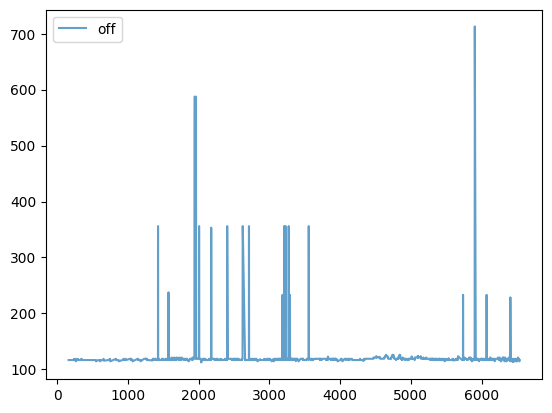

In [86]:
name = 'refill_m0.0'
# name = 'offline'
d = a[a[f'{name}_conf'] >= 0.7]
plt.plot(d[f'{name}_f0'], alpha=0.7)
print("Уверенных",len(d)/len(a))
# mean = d[f'{name}_f0'].mean()
mean = 116
ideal = 116.54
print('Попаданий',len(d[(d[f'{name}_f0'] <= 126) & (d[f'{name}_f0'] >= 116)])/len(d))
# plt.plot(d['refill_m0.0_f0'], alpha=0.7)
plt.legend(['off','z_1'])

<Axes: >

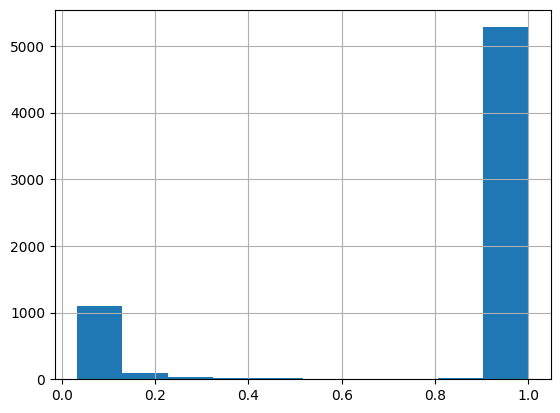

In [81]:
a[f'{name}_conf'].hist()

In [9]:
root = '../runs/pitch_eval/20260513_215529/A#2_260429_1923/'
for note in os.listdir(root):
    if os.path.isdir(os.path.join(root, note)):
        a = pd.read_csv(os.path.join(root, note, 'f0_curves.csv'))
        b = a[(a['detector']=='pesto') & (a['f0_hz'] > 1)]
        print(note)
        med = np.median(b['f0_hz'])
        print(((b['f0_hz'] > med*1.05) | (b['f0_hz'] < med*0.95)).mean())
        print('---')

In [12]:
b = pd.read_csv('../runs/pitch_eval/20260513_215529/A#2_260429_1923/f0_curves.csv')

In [13]:
b

,time_s,detector,f0_hz,confidence,signal_active
0,0.000000,yin,1005.5541,1.0000,0
1,0.023220,yin,0.0000,0.0000,0
2,0.046440,yin,0.0000,0.0000,0
3,0.069660,yin,0.0000,0.0000,0
4,0.092880,yin,0.0000,0.0000,0
...,...,...,...,...,...
9410,65.760002,pesto,0.0000,0.0735,0
9411,65.769997,pesto,0.0000,0.0747,0
9412,65.779999,pesto,0.0000,0.0750,0
9413,65.790001,pesto,0.0000,0.0645,0


In [14]:
c = b[(b['detector']=='pesto') & (b['f0_hz'] > 1)]
# plt.plot(c
# print(((c['f0_hz'] > 200) | (c['f0_hz'] < 170)).mean())

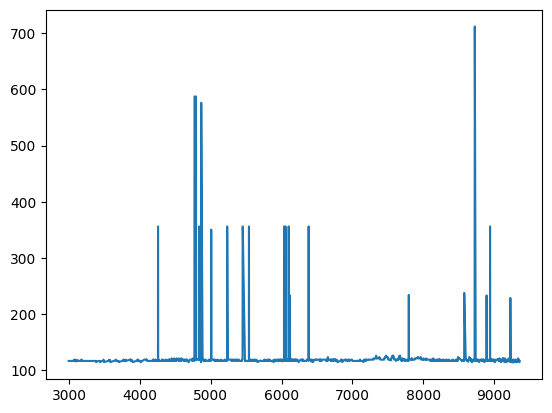

In [16]:
plt.plot(c['f0_hz'])